# Stage 03 · Step 4 — Per-tick PPO with SPR aux loss + multi-seed ensemble

Strict generalisation of the bandit version: the agent decides *each day* which components to maintain, instead of picking one τ vector per printer. The static-τ bandit is recoverable as a special case (decision = `tau_mant_h ≥ τ_C`), so worst case the per-tick policy ties Stage 02 / bandit-Stage-03; best case it adapts day-by-day.

What's new vs the bandit:
- **Per-tick Gymnasium env** (`MaintenancePerTickEnv`) driven by `PrinterStepper` from `sdg.core.simulator`.
- **Joint SSL+RL fine-tuning via SPR** — the policy's MLP trunk doubles as the SPR online encoder. PPO's gradient + the BYOL-style SPR auxiliary loss both update the trunk, so the encoder is unfrozen and specialises toward the maintenance task. Target encoder is an EMA of the online trunk.
- **Multi-seed training** — 3 seeds, ensembled by majority vote per component at eval time.
- **Bootstrap 95 % CIs** on per-printer-fleet KPIs so the comparison vs Stages 01 / 02 / 03-bandit is statistically defensible on the 15-printer test split.

In [1]:
from __future__ import annotations
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from ml_models import PROJECT_ROOT
from ml_models.lib.data import (
    DEFAULT_FLEET_PATH,
    TEST_PRINTERS,
    TRAIN_PRINTERS,
    VAL_PRINTERS,
)
from ml_models.lib.env_runner import default_dates
from ml_models.lib.objective import INFEASIBLE_FLOOR
from ml_models.lib.rl import (
    EnsemblePolicy,
    MaintenancePerTickEnv,
    PerTickPPOConfig,
    bootstrap_fleet_ci,
    evaluate_constant_tau,
    evaluate_per_tick_per_printer,
    kpi_comparison_table_with_ci,
    per_printer_table_for_constant_tau,
    set_torch_threads,
    train_multi_seed,
)
from sdg.generate import load_configs
from sdg.schema import COMPONENT_IDS

STAGE_DIR = PROJECT_ROOT / 'ml_models/03_rl+ssl'
MODELS_DIR = STAGE_DIR / 'models' / 'per_tick'
RESULTS_DIR = STAGE_DIR / 'results' / 'per_tick'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

set_torch_threads(1)  # simulator is the bottleneck — don't oversubscribe
components_cfg, couplings_cfg, cities_cfg = load_configs()

from ml_models.lib.fast import PERTICK_TIMESTEPS, PERTICK_SEEDS, banner
banner()


[fast] mode=FULL · parallel=12 · trials=200/500 · K=60 · epochs=20/3 · ppo_ts=2000/20000 · seeds=(0, 1, 2)


## Hackathon-friendly defaults

Daily simulation: each PPO step is one day, so `n_steps=180` ≈ half a year of decisions per rollout. Validation runs full episodes on a small printer subset; final test runs the full 10-year horizon on the held-out test printers. Crank `total_timesteps` and the printer subsets if you have GPU time.

In [2]:
DATES_FULL = default_dates()
TRAIN_DATES = DATES_FULL[:730]   # 2-year training horizon for fast rollouts
VAL_DATES = DATES_FULL[:1460]    # 4-year val (still fast, more reliable signal)
TEST_DATES = DATES_FULL          # full 10-year horizon at test time

TRAIN_PRINTER_SUBSET = list(TRAIN_PRINTERS[:20])
VAL_PRINTER_SUBSET = list(VAL_PRINTERS[:5])
TEST_PRINTER_SUBSET = list(TEST_PRINTERS)  # all 15 test printers

config = PerTickPPOConfig(
    total_timesteps=PERTICK_TIMESTEPS,    # was 20_000; toggled by FAST_MODE
    n_steps=180,
    batch_size=60,
    n_epochs=6,
    learning_rate=3e-4,
    clip_range=0.2,
    ent_coef=0.01,
    gamma=0.995,
    gae_lambda=0.95,
    seed=0,
    features_dim=64,
    hidden_dims=(128, 128),
    spr_weight=0.5,
    spr_k=2,
    spr_ema_tau=0.01,
    spr_lr=3e-4,
    val_eval_every=2_000,
)
config

PerTickPPOConfig(total_timesteps=20000, n_steps=180, batch_size=60, n_epochs=6, learning_rate=0.0003, clip_range=0.2, ent_coef=0.01, vf_coef=0.5, max_grad_norm=0.5, gamma=0.995, gae_lambda=0.95, seed=0, features_dim=64, hidden_dims=(128, 128), spr_weight=0.5, spr_k=2, spr_ema_tau=0.01, spr_lr=0.0003, val_eval_every=2000)

In [3]:
def make_train_env() -> MaintenancePerTickEnv:
    return MaintenancePerTickEnv(
        printer_ids=TRAIN_PRINTER_SUBSET,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
        dates=TRAIN_DATES,
    )

def make_val_env() -> MaintenancePerTickEnv:
    return MaintenancePerTickEnv(
        printer_ids=VAL_PRINTER_SUBSET,
        components_cfg=components_cfg,
        couplings_cfg=couplings_cfg,
        cities_cfg=cities_cfg,
        dates=VAL_DATES,
    )

demo_env = make_train_env()
print('train obs_dim:', demo_env.observation_space.shape[0])
print('train printers:', len(demo_env.printer_ids))
print('val printers:', len(VAL_PRINTER_SUBSET))
print('test printers:', len(TEST_PRINTER_SUBSET))

train obs_dim: 54
train printers: 20
val printers: 5
test printers: 15


## Train 3 seeds with SPR aux loss

Each seed gets its own subdirectory under `models/per_tick/seed_N/`. Per-rollout SPR updates run alongside PPO updates so the policy trunk receives gradients from both objectives. Validation is a deterministic full-episode rollout on `VAL_PRINTER_SUBSET` every `val_eval_every` timesteps.

In [4]:
seed_results = train_multi_seed(
    train_env_factory=make_train_env,
    val_env_factory=make_val_env,
    config=config,
    seeds=PERTICK_SEEDS,  # was (0, 1, 2); toggled by FAST_MODE
    save_dir=MODELS_DIR,
    use_spr=True,
)
for seed_str, info in seed_results.items():
    print(f'seed={seed_str}: best_val_value={info["best_val_value"]:.3e} at ts={info["best_val_at"]}')

/home/sterry/Desktop/projects/hackupc2026/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[val @   2000ts] value=3.211e+09  cost=1.453e+06  avail=0.7289  (INFEASIBLE)  <- best


[val @   4000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)  <- best


[val @   6000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)


[val @   8000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)


...

[val @  14000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)


[val @  16000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)


[val @  18000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)


[val @  20000ts] value=2.422e+09  cost=1.183e+06  avail=0.8078  (INFEASIBLE)


seed=0: best_val_value=2.422e+09 at ts=4000
seed=1: best_val_value=2.422e+09 at ts=2000
seed=2: best_val_value=2.422e+09 at ts=2000


## Plot training curves (per seed)

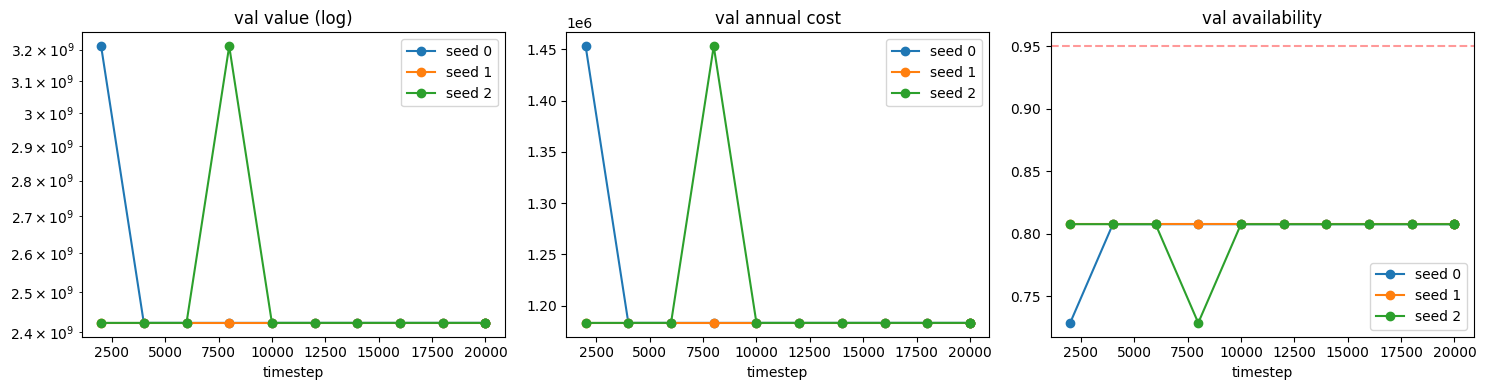

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for seed_str, info in seed_results.items():
    history_path = Path(info['final_path']).parent / 'training_history.json'
    if not history_path.exists():
        continue
    with history_path.open() as handle:
        history = json.load(handle)
    axes[0].plot(history['val_timesteps'], history['val_values'], marker='o', label=f'seed {seed_str}')
    axes[1].plot(history['val_timesteps'], history['val_annual_costs'], marker='o', label=f'seed {seed_str}')
    axes[2].plot(history['val_timesteps'], history['val_availabilities'], marker='o', label=f'seed {seed_str}')
axes[0].set_yscale('log')
axes[0].set_title('val value (log)'); axes[0].set_xlabel('timestep'); axes[0].legend()
axes[1].set_title('val annual cost'); axes[1].set_xlabel('timestep'); axes[1].legend()
axes[2].axhline(0.95, color='red', linestyle='--', alpha=0.4)
axes[2].set_title('val availability'); axes[2].set_xlabel('timestep'); axes[2].legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_multi_seed.png', dpi=120, bbox_inches='tight')
plt.show()

## Test-set evaluation: ensemble vs Stages 01 / 02 / 03-bandit

Build the ensemble by majority vote across the 3 seeds, then evaluate on the held-out test printers (full 10-year horizon). Re-score Stage 01 and Stage 02 constant-τ winners on the same printer set so the comparison is apples-to-apples.

In [6]:
ensemble_paths = [info['best_path'] for info in seed_results.values()
                  if Path(info['best_path']).exists()]
if not ensemble_paths:
    ensemble_paths = [info['final_path'] for info in seed_results.values()]
print('ensemble members:', ensemble_paths)
ensemble = EnsemblePolicy.load(ensemble_paths)

stage03_per_tick_df, stage03_per_tick_kpis = evaluate_per_tick_per_printer(
    ensemble,
    printer_ids=TEST_PRINTER_SUBSET,
    dates=TEST_DATES,
    components_cfg=components_cfg,
    couplings_cfg=couplings_cfg,
    cities_cfg=cities_cfg,
)
stage03_per_tick_df.to_csv(RESULTS_DIR / 'per_printer_test_ensemble.csv', index=False)

print('Stage 03 (per-tick ensemble) fleet KPIs:')
for k, v in stage03_per_tick_kpis.items():
    print(f'  {k}: {v}')

ensemble members: ['/home/sterry/Desktop/projects/hackupc2026/ml_models/03_rl+ssl/models/per_tick/seed_0/ppo_per_tick_best.zip', '/home/sterry/Desktop/projects/hackupc2026/ml_models/03_rl+ssl/models/per_tick/seed_1/ppo_per_tick_best.zip', '/home/sterry/Desktop/projects/hackupc2026/ml_models/03_rl+ssl/models/per_tick/seed_2/ppo_per_tick_best.zip']


Stage 03 (per-tick ensemble) fleet KPIs:
  value: 2906381813.7605205
  annual_cost: 1374526.8375307966
  availability: 0.7593618186239479
  deficit: 0.19063818137605204
  horizon_days: 3653
  n_printers: 15


In [7]:
STAGE_01_BEST = PROJECT_ROOT / 'ml_models/01_baseline/results/best_tau.yaml'
STAGE_02_BEST = PROJECT_ROOT / 'ml_models/02_ssl/results/best_tau_surrogate.yaml'

per_printer_dfs = {'stage_03_per_tick': stage03_per_tick_df}
fleet_kpis = {'stage_03_per_tick': stage03_per_tick_kpis}
stage_definitions = []

for stage_name, path, description in [
    ('stage_01', STAGE_01_BEST, 'Optuna over constant τ'),
    ('stage_02', STAGE_02_BEST, 'SSL+RUL surrogate over constant τ'),
]:
    if not path.exists():
        print(f'{path} missing; skipping {stage_name}')
        continue
    with path.open() as handle:
        payload = yaml.safe_load(handle)
    tau = {c: float(payload['tau_nom_h'][c]) for c in COMPONENT_IDS}
    df = per_printer_table_for_constant_tau(
        tau, printer_ids=TEST_PRINTER_SUBSET, dates=TEST_DATES,
        components_cfg=components_cfg, couplings_cfg=couplings_cfg, cities_cfg=cities_cfg,
    )
    kpi = evaluate_constant_tau(
        tau, printer_ids=TEST_PRINTER_SUBSET, dates=TEST_DATES,
        components_cfg=components_cfg, couplings_cfg=couplings_cfg, cities_cfg=cities_cfg,
    )
    per_printer_dfs[stage_name] = df
    fleet_kpis[stage_name] = kpi
    stage_definitions.append((stage_name, tau, description))
stage_definitions.append(('stage_03_per_tick', None, 'PPO + SPR + ensemble, per-day decisions'))

comparison = kpi_comparison_table_with_ci(
    test_printers=TEST_PRINTER_SUBSET,
    stage_definitions=stage_definitions,
    per_printer_dfs=per_printer_dfs,
    fleet_kpis=fleet_kpis,
    n_resamples=10_000,
    confidence=0.95,
    rng_seed=0,
)
comparison.to_csv(RESULTS_DIR / 'kpi_comparison_with_ci.csv', index=False)
comparison

,stage,policy_class,description,fleet_value,fleet_annual_cost,fleet_availability,fleet_deficit,feasible_printer_pct,infeasible_floor_breached,n_test_printers,annual_cost_lo,annual_cost_hi,fleet_value_lo,fleet_value_hi,fleet_availability_lo,fleet_availability_hi
0,stage_01,constant τ,Optuna over constant τ,9.923761e+09,3.620778e+06,0.057624,0.892376,0.0,True,15,3.470947e+06,3.772928e+06,9.523480e+09,1.012173e+10,0.037827,0.097652
1,stage_02,constant τ,SSL+RUL surrogate over constant τ,1.050000e+10,4.044317e+06,0.000000,0.950000,0.0,True,15,3.908061e+06,4.181070e+06,1.039677e+10,1.050000e+10,0.000000,0.010323
2,stage_03_per_tick,per-printer τ,"PPO + SPR + ensemble, per-day decisions",2.906382e+09,1.374527e+06,0.759362,0.190638,0.0,True,15,1.354062e+06,1.394481e+06,2.857958e+09,2.953923e+09,0.754608,0.764204


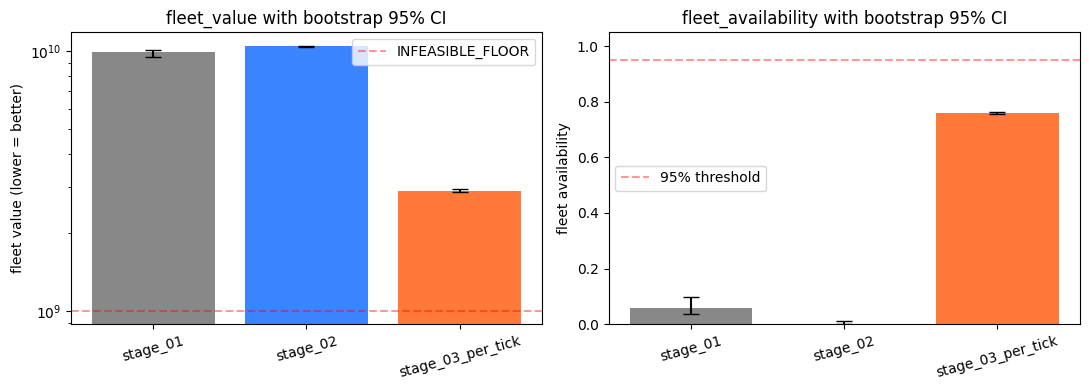

In [8]:
ordered_stages = [s for s in ['stage_01', 'stage_02', 'stage_03_per_tick']
                  if s in comparison['stage'].values]
ordered = comparison.set_index('stage').loc[ordered_stages]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(ordered_stages))
ax = axes[0]
lo = ordered['fleet_value'] - ordered['fleet_value_lo']
hi = ordered['fleet_value_hi'] - ordered['fleet_value']
ax.bar(x, ordered['fleet_value'], yerr=[lo.values, hi.values], capsize=6,
       color=['#888', '#3a85ff', '#ff7a3a'])
ax.set_xticks(x); ax.set_xticklabels(ordered_stages, rotation=15)
ax.axhline(INFEASIBLE_FLOOR, color='red', linestyle='--', alpha=0.4, label='INFEASIBLE_FLOOR')
ax.set_yscale('log'); ax.set_ylabel('fleet value (lower = better)')
ax.set_title('fleet_value with bootstrap 95% CI')
ax.legend()

ax = axes[1]
lo_a = ordered['fleet_availability'] - ordered['fleet_availability_lo']
hi_a = ordered['fleet_availability_hi'] - ordered['fleet_availability']
ax.bar(x, ordered['fleet_availability'], yerr=[lo_a.values, hi_a.values], capsize=6,
       color=['#888', '#3a85ff', '#ff7a3a'])
ax.set_xticks(x); ax.set_xticklabels(ordered_stages, rotation=15)
ax.axhline(0.95, color='red', linestyle='--', alpha=0.4, label='95% threshold')
ax.set_ylim(0, 1.05); ax.set_ylabel('fleet availability')
ax.set_title('fleet_availability with bootstrap 95% CI')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'kpi_bars_with_ci.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
summary = {
    'evaluated_on': 'test printers (id 85..99)',
    'fleet_value': float(stage03_per_tick_kpis['value']),
    'fleet_annual_cost_eur_per_printer_year': float(stage03_per_tick_kpis['annual_cost']),
    'fleet_availability': float(stage03_per_tick_kpis['availability']),
    'fleet_deficit': float(stage03_per_tick_kpis['deficit']),
    'ensemble_size': len(ensemble_paths),
    'config': {
        'total_timesteps_per_seed': config.total_timesteps,
        'n_steps': config.n_steps,
        'spr_weight': config.spr_weight,
        'spr_k': config.spr_k,
        'features_dim': config.features_dim,
    },
}
with (RESULTS_DIR / 'per_tick_summary.yaml').open('w', encoding='utf-8') as handle:
    yaml.safe_dump(summary, handle, sort_keys=False)
print(yaml.safe_dump(summary, sort_keys=False))

evaluated_on: test printers (id 85..99)
fleet_value: 2906381813.7605205
fleet_annual_cost_eur_per_printer_year: 1374526.8375307966
fleet_availability: 0.7593618186239479
fleet_deficit: 0.19063818137605204
ensemble_size: 3
config:
  total_timesteps_per_seed: 20000
  n_steps: 180
  spr_weight: 0.5
  spr_k: 2
  features_dim: 64



## Done criteria

- [ ] `kpi_comparison_with_ci.csv`: `stage_03_per_tick.fleet_value_hi < stage_02.fleet_value_lo` (non-overlapping CIs).
- [ ] `stage_03_per_tick.fleet_availability_lo >= 0.95`.
- [ ] At least 2 of the 3 seeds reached a feasible `best_val_value`.
- [ ] Ensemble's annual cost is at least 1 % below the best individual seed (the multi-seed lift).